<p style="font-family:Bookman Old Style;font-size:27px; text-align:center">
Comparing the runtimes of SciPy convolve() and
fftconvolve() with the Gaussian blur kernel</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">We can leverage the Python timeit module to assess the performance differences between convolution functions in the image domain and the frequency domain. Since convolution in the frequency domain involves a single matrix multiplication, in contrast to the multiple sliding window operations required in the image domain, we expect it to deliver much faster results.</p></div>


<p style="font-family:Bookman Old Style;font-size:27px">Import libraries</p>

In [51]:
import cv2
import scipy
import numpy as np
from scipy.signal.windows import gaussian
import matplotlib.pyplot as plt
import timeit

<p style="font-family:Bookman Old Style;font-size:27px">Image Loading and Preprocessing</p>

In [52]:
img = cv2.imread('../images-videos/lenna.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

<p style="font-family:Bookman Old Style;font-size:27px">Gaussian Kernel Creation</p>

In [53]:
gauss_kernel = np.outer(gaussian(11, 3), gaussian(11, 3))

<p style="font-family:Bookman Old Style;font-size:27px">Image Blurring Using Convolution</p>

In [54]:
im_blurred1 = scipy.signal.convolve(img_gray, gauss_kernel, mode='same')
im_blurred2 = scipy.signal.fftconvolve(img_gray, gauss_kernel, mode='same')

<p style="font-family:Bookman Old Style;font-size:27px">Displaying Original and Blurred Images</p>

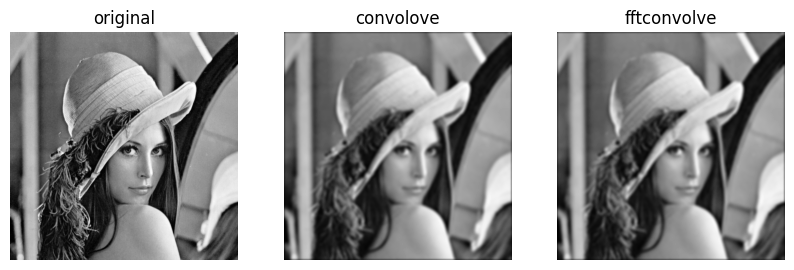

In [55]:
plt.figure(figsize=(10, 5))

plt.subplot(131)
plt.imshow(img_gray, cmap='gray')
plt.title('original')
plt.axis('off')

plt.subplot(132)
plt.imshow(im_blurred1, cmap='gray')
plt.title('convolove')
plt.axis('off')

plt.subplot(133)
plt.imshow(im_blurred2, cmap='gray')
plt.title('fftconvolve')
plt.axis('off')
plt.show()

<p style="font-family:Bookman Old Style;font-size:27px">Function Definition for Convolution Wrapper</p>

In [56]:
def convolved(func):
    def wrapped_conv():
        return func(img_gray, gauss_kernel, mode='same')
    return wrapped_conv

<p style="font-family:Bookman Old Style;font-size:27px">Creating Wrapped Convolution Functions</p>

In [57]:
conv = convolved(scipy.signal.convolve)
fftconv = convolved(scipy.signal.fftconvolve)

<p style="font-family:Bookman Old Style;font-size:27px">Timing the Execution of Convolution Methods</p>

In [58]:
times1 = timeit.repeat(conv, number=1, repeat=100)
times2 = timeit.repeat(fftconv, number=1, repeat=100)

<p style="font-family:Bookman Old Style;font-size:27px">Preparing Data for Boxplot Visualization</p>

In [59]:
data = [times1, times2]

<p style="font-family:Bookman Old Style;font-size:27px">Boxplot Visualization of Execution Times</p>

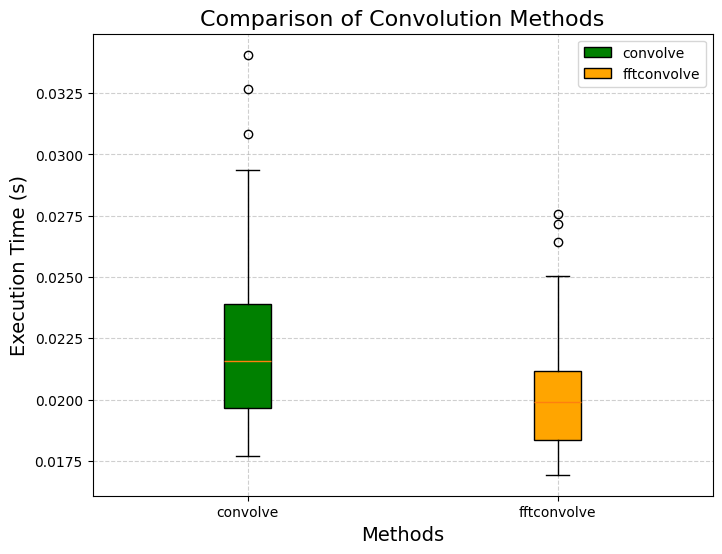

In [60]:
plt.figure(figsize=(8, 6))
box = plt.boxplot(data, patch_artist=True, tick_labels=['convolve', 'fftconvolve'])
colors = ['green', 'orange']

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Comparison of Convolution Methods', size=16)
plt.xlabel('Methods', size=14)
plt.ylabel('Execution Time (s)', size=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend([box['boxes'][0], box['boxes'][1]], ['convolve', 'fftconvolve'], loc='upper right')
plt.show()